# A_S1.1 — Scatterplot Visualization of Four Relationship Categories

| f(X) | σ(X) | Category | Meaning |
|------|------|----------|---------|
| Constant | Constant | **True Null** | Y is independent of X |
| Varying | Constant | **Mean-only** | E[Y\|X] depends on X, constant spread |
| Constant | Varying | **Variance-only** | E[Y\|X] = 0, but Var[Y\|X] depends on X |
| Varying | Varying | **Mean + Variance** | Both mean and spread depend on X |

Each scatterplot overlays:
- **Red line**: true f(X)
- **Red band**: ±2σ(X) envelope

In [2]:
from __future__ import annotations
import json as _json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATA_DIR = Path('output/S1')
OUT_DIR = Path('output/S1/viz')
OUT_DIR.mkdir(parents=True, exist_ok=True)

cases = pd.read_csv(DATA_DIR / 'cases.csv', low_memory=False)
pts = np.load(DATA_DIR / 'scatter_points.npz')
x_all = pts['x']
y_all = pts['y']

is_null = cases['family_id'] == 'Null'
is_const = cases['spread_pattern'] == 'constant'
cases['category'] = 'mean+variance'
cases.loc[is_null & is_const, 'category'] = 'true_null'
cases.loc[~is_null & is_const, 'category'] = 'mean_only'
cases.loc[is_null & ~is_const, 'category'] = 'variance_only'

print(f'Loaded {len(cases):,} cases × {x_all.shape[1]} points')
print(cases['category'].value_counts())

Loaded 114,176 cases × 500 points
category
mean+variance    85536
mean_only        28512
variance_only       96
true_null           32
Name: count, dtype: int64


In [3]:
# --------------- signal & spread functions (from S1) ---------------

_NEGATIVE_COUNTERPART = {
    'F04': 'F03', 'F06': 'F05', 'F08': 'F07', 'F10': 'F09',
    'F12': 'F11', 'F14': 'F13', 'F16': 'F15',
}

def _triangular_local(x, center, width):
    return np.maximum(0.0, 1.0 - np.abs(x - center) / width)

def evaluate_signal(x, family_id, params):
    x = np.asarray(x, dtype=float)
    p = params
    fid = family_id
    if fid in _NEGATIVE_COUNTERPART:
        return -evaluate_signal(x, _NEGATIVE_COUNTERPART[fid], params)
    if fid in {'F01', 'F02'}:
        return p['slope'] * x + p.get('intercept', 0.0)
    if fid in {'F03', 'F05'}:
        return x ** p['p']
    if fid == 'F07':
        return 1.0 - np.exp(-p['k'] * x)
    if fid == 'F09':
        return np.log1p(p['a'] * x)
    if fid == 'F11':
        return p['base'] ** (x * p['x_range'])
    if fid == 'F13':
        return p['L1'] + (p['L2'] - p['L1']) / (1.0 + np.exp(-p['k'] * (x - p['c'])))
    if fid == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return p['a'] + (p['b'] - p['a']) * t
    if fid == 'F17':
        return -p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F18':
        return p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F19':
        return _triangular_local(x, p['c'], p['width'])
    if fid == 'F20':
        return 1.0 - _triangular_local(x, p['c'], p['width'])
    if fid == 'F21':
        r1, r2, r3 = p['roots']
        return p['a'] * (x - r1) * (x - r2) * (x - r3) + p['d']
    if fid == 'F22':
        vn = params.get('_variant', '')
        if 'double_gaussian' in vn:
            return (p['A1'] * np.exp(-((x - p['mu1'])**2) / p['sigma1']**2)
                  + p['A2'] * np.exp(-((x - p['mu2'])**2) / p['sigma2']**2))
        if 'pure_osc' in vn:
            return p['A'] * np.sin(p['omega'] * x)
        if 'oscillation_trend' in vn:
            return p['b'] * x + p['A'] * np.sin(p['omega'] * x)
        if vn == 'damped_oscillation':
            return p['A'] * np.exp(-p['lambda'] * x) * np.sin(p['omega'] * x)
        if vn == 'growing_oscillation':
            return p['A'] * np.exp(p['lambda'] * x) * np.sin(p['omega'] * x)
        if vn == 'varying_frequency':
            return p['A'] * np.sin(p['omega'] * x * (1.0 + x))
        return np.zeros_like(x)
    if fid == 'Null':
        return np.zeros_like(x)
    return np.zeros_like(x)


def spread_multiplier(x, pattern):
    x = np.asarray(x, dtype=float)
    if pattern == 'constant':
        return np.ones_like(x)
    if pattern == 'increasing':
        return 0.2 + 1.6 * x
    if pattern == 'decreasing':
        return 1.8 - 1.6 * x
    if pattern == 'middle_high':
        return 0.3 + 1.4 * np.exp(-((x - 0.5)**2) / 0.02)
    return np.ones_like(x)


def sigma0_for_snr(family_id, params, snr):
    if math.isinf(snr):
        return 0.0
    x_grid = np.linspace(0, 1, 10000)
    var_signal = np.var(evaluate_signal(x_grid, family_id, params), ddof=0)
    if var_signal <= 0:
        return 0.0
    return math.sqrt(var_signal / snr)


def get_case_info(case_id):
    row = cases[cases['case_id'] == case_id].iloc[0]
    fid = row['family_id']
    params = _json.loads(row['params_json'])
    params['_variant'] = row['variant_name']
    spread = row['spread_pattern']
    snr = float('inf') if str(row['snr']) == 'inf' else float(row['snr'])
    return fid, params, spread, snr


def plot_case(ax, case_id, title=None, color='#4a90d9', alpha=0.3, s=8,
              show_signal=True, show_envelope=True):
    x = x_all[case_id]
    y = y_all[case_id]
    ax.scatter(x, y, s=s, alpha=alpha, color=color, edgecolors='none', zorder=1)

    if show_signal or show_envelope:
        fid, params, spread, snr = get_case_info(case_id)
        x_line = np.linspace(x.min(), x.max(), 300)
        y_signal = evaluate_signal(x_line, fid, params)

        if show_signal and fid != 'Null':
            ax.plot(x_line, y_signal, color='#dc2626', lw=2, zorder=3, label='f(X)')

        if show_envelope:
            if fid == 'Null':
                base_sigma = 1.0
            else:
                base_sigma = sigma0_for_snr(fid, params, snr)
            sigma = base_sigma * spread_multiplier(x_line, spread)
            if sigma.max() > 1e-10:
                ax.fill_between(x_line, y_signal - 2*sigma, y_signal + 2*sigma,
                                color='#dc2626', alpha=0.12, zorder=2, label='±2σ(X)')

    if title:
        ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7)


def find_case(family_id='Null', spread='constant', x_dist='even', snr=None):
    mask = ((cases['family_id'] == family_id) &
            (cases['spread_pattern'] == spread) &
            (cases['x_distribution'] == x_dist))
    if snr is not None:
        mask &= cases['snr'] == snr
    matches = cases[mask]
    if len(matches) == 0:
        return None
    return matches.iloc[0]['case_id']

print('Helpers ready')

Helpers ready


## Figure 1 — The Four Categories (2×2 Grid)

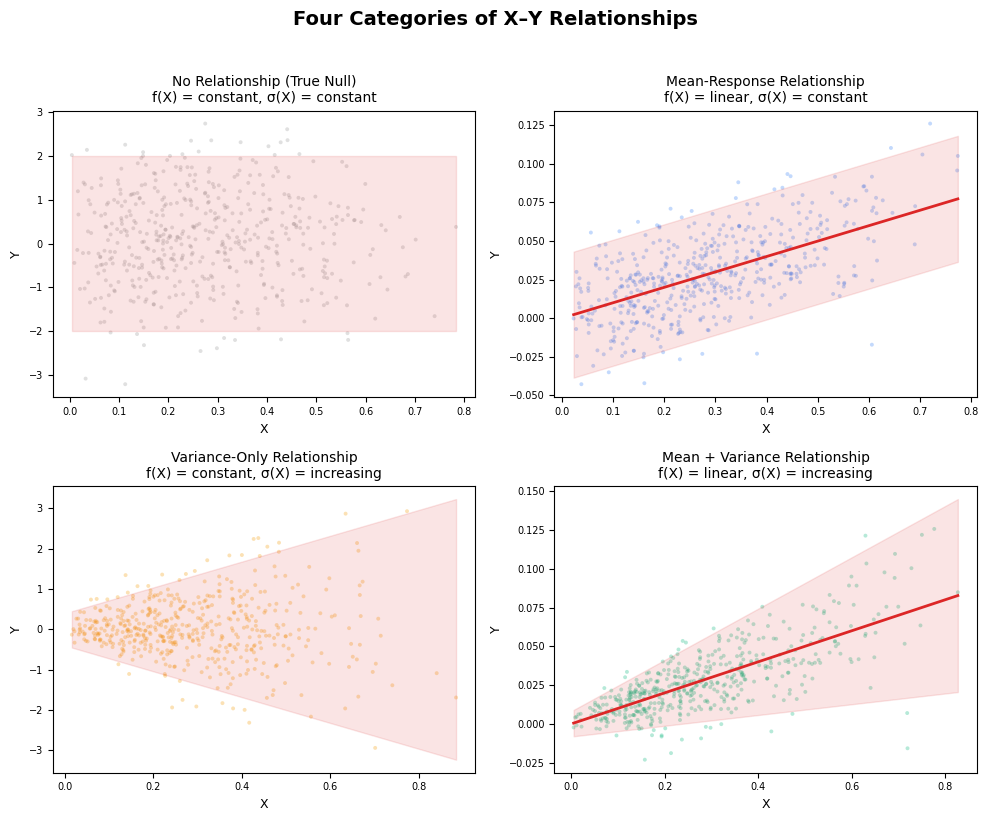

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

cid = find_case('Null', 'constant', 'even')
plot_case(axes[0, 0], cid, color='#999999')
axes[0, 0].set_title('No Relationship (True Null)\nf(X) = constant, σ(X) = constant', fontsize=10)

cid = find_case('F01', 'constant', 'even', snr=2.0)
plot_case(axes[0, 1], cid, color='#3b82f6')
axes[0, 1].set_title('Mean-Response Relationship\nf(X) = linear, σ(X) = constant', fontsize=10)

cid = find_case('Null', 'increasing', 'even')
plot_case(axes[1, 0], cid, color='#f59e0b')
axes[1, 0].set_title('Variance-Only Relationship\nf(X) = constant, σ(X) = increasing', fontsize=10)

cid = find_case('F01', 'increasing', 'even', snr=2.0)
plot_case(axes[1, 1], cid, color='#10b981')
axes[1, 1].set_title('Mean + Variance Relationship\nf(X) = linear, σ(X) = increasing', fontsize=10)

for ax in axes.flat:
    ax.set_xlabel('X', fontsize=9)
    ax.set_ylabel('Y', fontsize=9)

plt.suptitle('Four Categories of X–Y Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig1_four_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Mean-Response: Diverse Function Shapes

All with `spread=constant`, `snr=2.0`, `x_dist=even`.

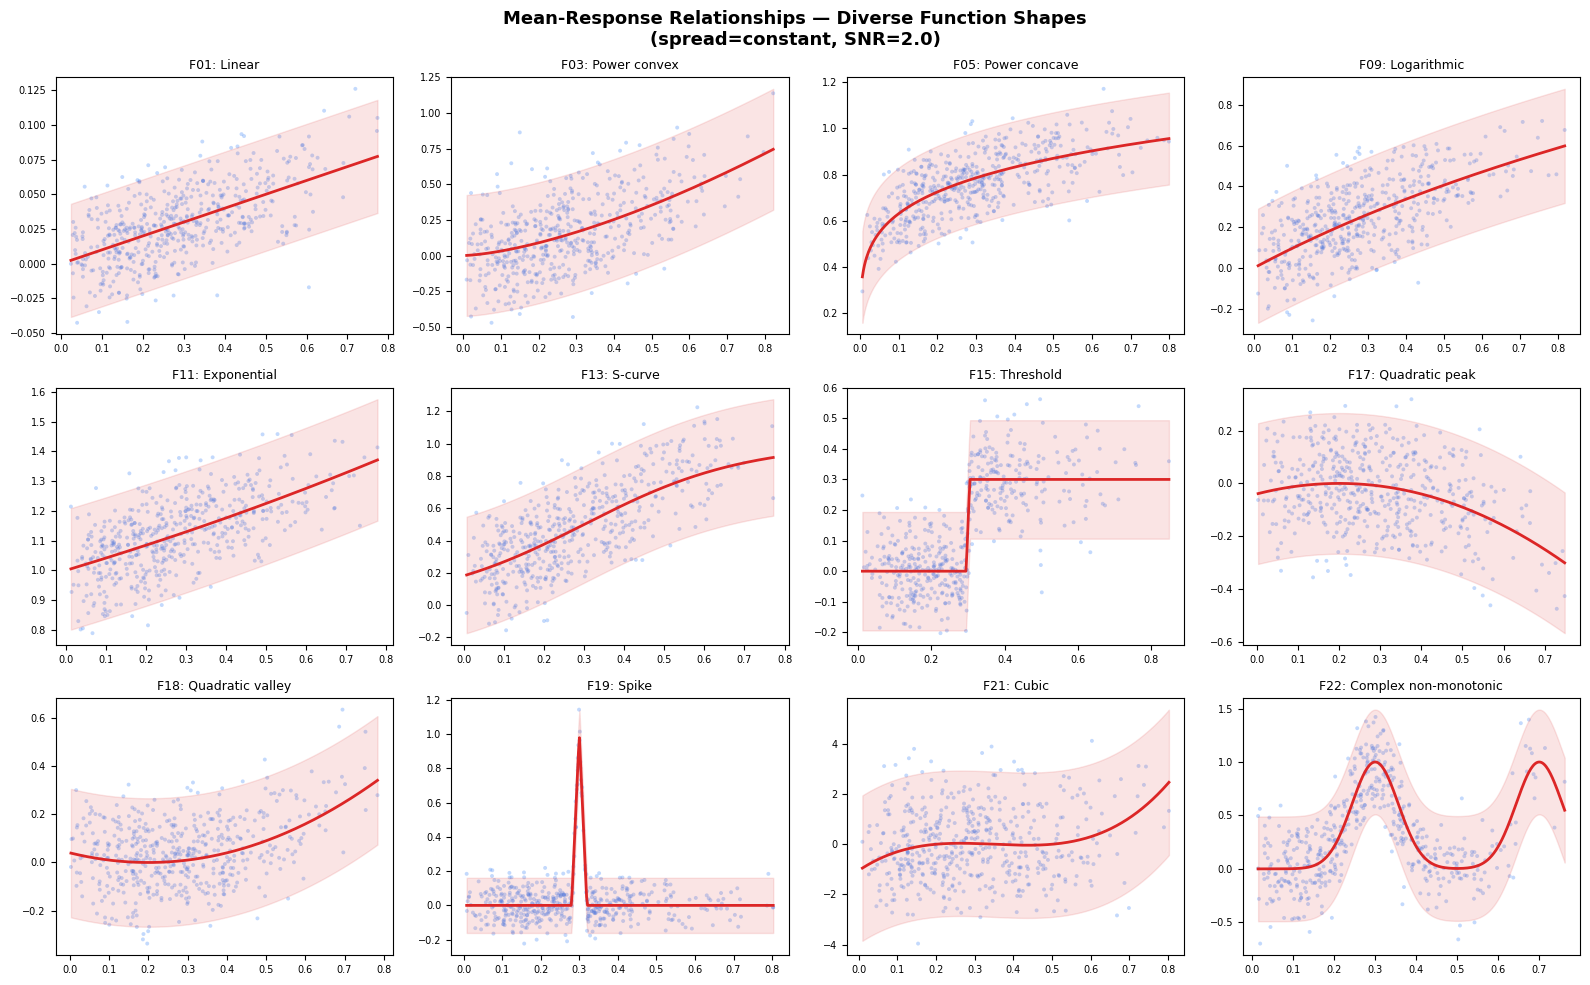

In [5]:
families_to_show = [
    ('F01', 'Linear'), ('F03', 'Power convex'), ('F05', 'Power concave'),
    ('F09', 'Logarithmic'), ('F11', 'Exponential'), ('F13', 'S-curve'),
    ('F15', 'Threshold'), ('F17', 'Quadratic peak'), ('F18', 'Quadratic valley'),
    ('F19', 'Spike'), ('F21', 'Cubic'), ('F22', 'Complex non-monotonic'),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (fam, label) in zip(axes.flat, families_to_show):
    cid = find_case(fam, 'constant', 'even', snr=2.0)
    if cid is not None:
        plot_case(ax, cid, color='#3b82f6')
    ax.set_title(f'{fam}: {label}', fontsize=9)

plt.suptitle('Mean-Response Relationships — Diverse Function Shapes\n(spread=constant, SNR=2.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_mean_response_shapes.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — SNR Effect

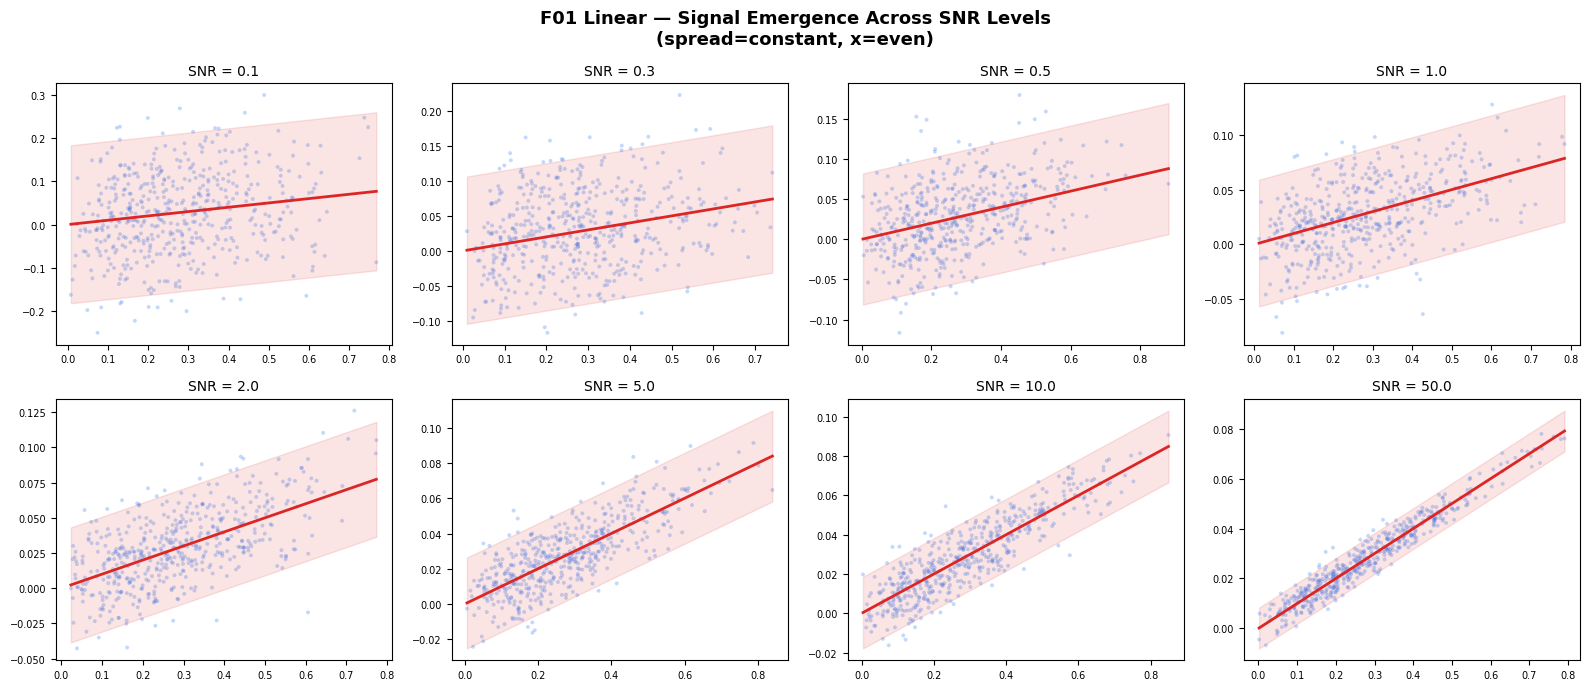

In [6]:
snr_values = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, snr in zip(axes.flat, snr_values):
    cid = find_case('F01', 'constant', 'even', snr=snr)
    if cid is not None:
        plot_case(ax, cid, color='#3b82f6')
    ax.set_title(f'SNR = {snr}', fontsize=10)

plt.suptitle('F01 Linear — Signal Emergence Across SNR Levels\n(spread=constant, x=even)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig3_snr_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Variance-Only: Spread Patterns

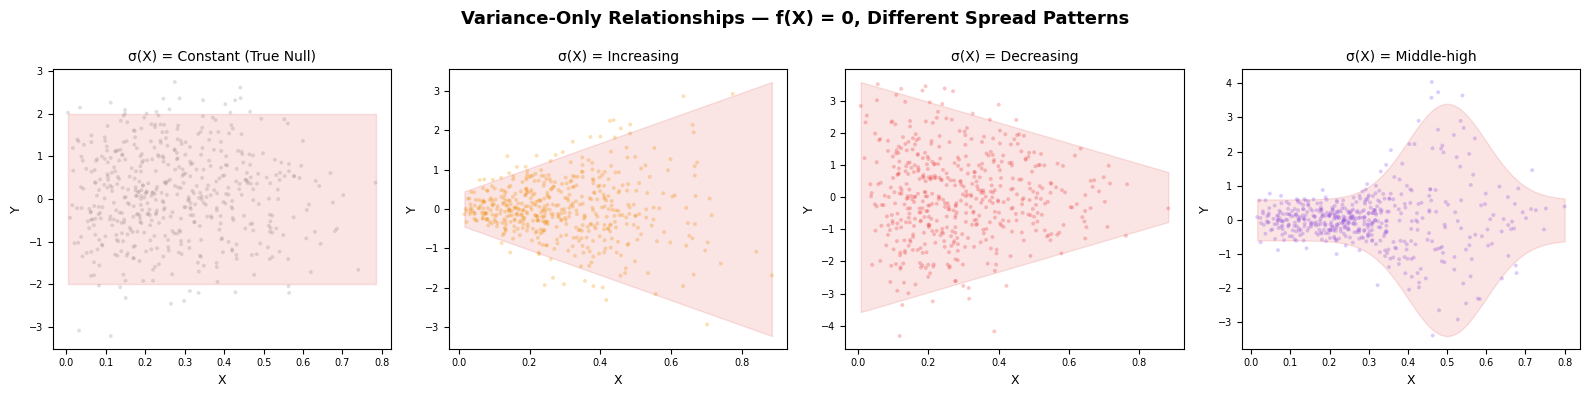

In [7]:
spread_patterns = ['constant', 'increasing', 'decreasing', 'middle_high']
spread_labels = ['Constant (True Null)', 'Increasing', 'Decreasing', 'Middle-high']
spread_colors = ['#999999', '#f59e0b', '#ef4444', '#8b5cf6']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, sp, label, color in zip(axes, spread_patterns, spread_labels, spread_colors):
    cid = find_case('Null', sp, 'even')
    if cid is not None:
        plot_case(ax, cid, color=color)
    ax.set_title(f'σ(X) = {label}', fontsize=10)
    ax.set_xlabel('X', fontsize=9)
    ax.set_ylabel('Y', fontsize=9)

plt.suptitle('Variance-Only Relationships — f(X) = 0, Different Spread Patterns',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig4_variance_only_spreads.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — Mean + Variance: Same Function, Different Spreads

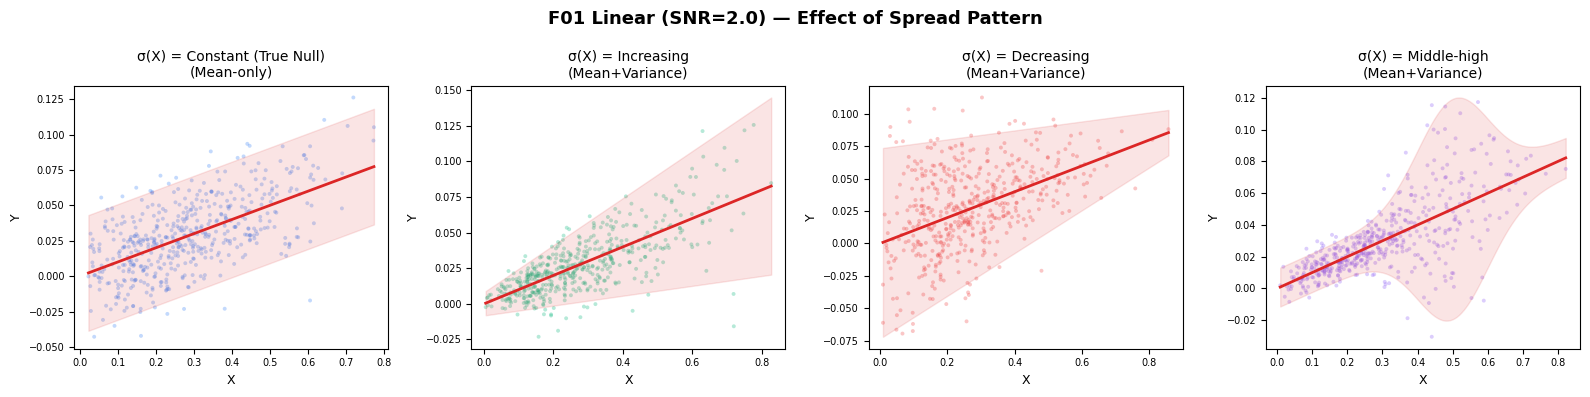

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, sp, label, color in zip(axes, spread_patterns, spread_labels,
                                 ['#3b82f6', '#10b981', '#ef4444', '#8b5cf6']):
    cid = find_case('F01', sp, 'even', snr=2.0)
    if cid is not None:
        plot_case(ax, cid, color=color)
    cat = 'Mean-only' if sp == 'constant' else 'Mean+Variance'
    ax.set_title(f'σ(X) = {label}\n({cat})', fontsize=10)
    ax.set_xlabel('X', fontsize=9)
    ax.set_ylabel('Y', fontsize=9)

plt.suptitle('F01 Linear (SNR=2.0) — Effect of Spread Pattern',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig5_mean_plus_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — Nonlinear × Spread Interaction Grid

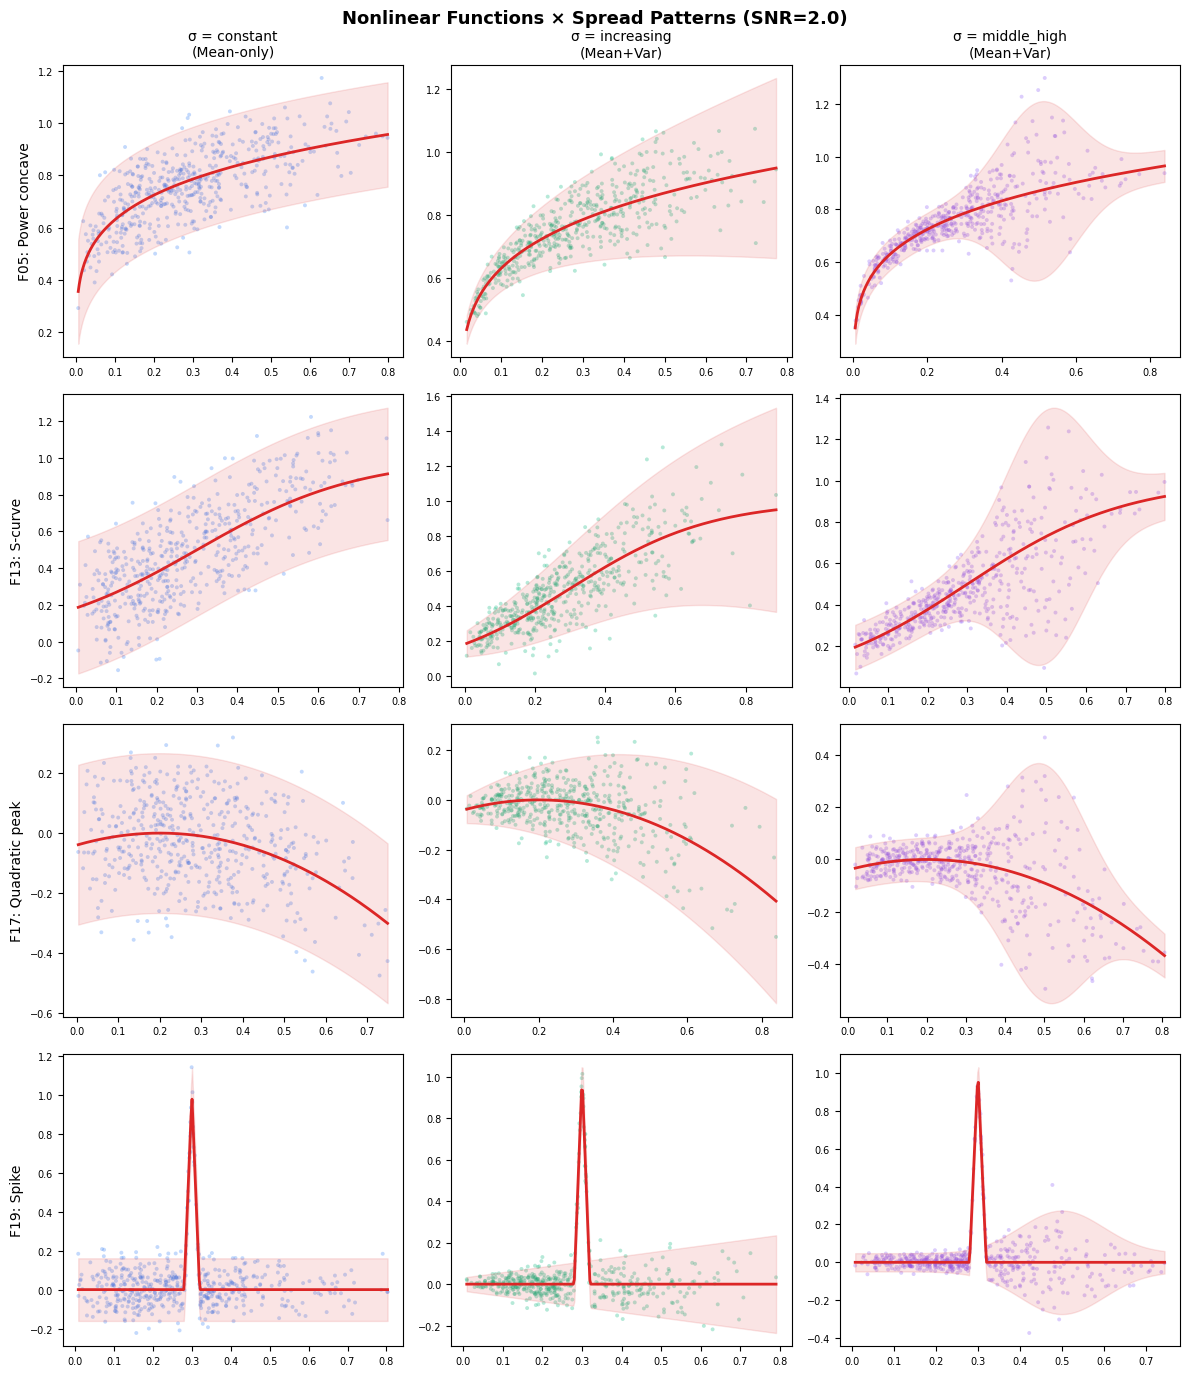

In [9]:
fam_for_grid = [
    ('F05', 'Power concave'), ('F13', 'S-curve'),
    ('F17', 'Quadratic peak'), ('F19', 'Spike'),
]
spreads_for_grid = ['constant', 'increasing', 'middle_high']
spread_labels_short = ['σ = constant\n(Mean-only)', 'σ = increasing\n(Mean+Var)', 'σ = middle_high\n(Mean+Var)']
col_colors = ['#3b82f6', '#10b981', '#8b5cf6']

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for row, (fam, fam_label) in enumerate(fam_for_grid):
    for col, (sp, sp_label, color) in enumerate(zip(spreads_for_grid, spread_labels_short, col_colors)):
        ax = axes[row, col]
        cid = find_case(fam, sp, 'even', snr=2.0)
        if cid is not None:
            plot_case(ax, cid, color=color)
        if row == 0:
            ax.set_title(sp_label, fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{fam}: {fam_label}', fontsize=10)

plt.suptitle('Nonlinear Functions × Spread Patterns (SNR=2.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig6_nonlinear_spread_grid.png', dpi=150, bbox_inches='tight')
plt.show()